# Entrega Final: Predicción de Tendencia de Bitcoin con Modelos de Ensamble

### 1. Abstracto
Este proyecto representa la evolución de un análisis financiero descriptivo previo hacia la implementación de un sistema predictivo robusto basado en **Machine Learning**. Utilizando datos históricos de precios de activos, el estudio modela la situación como un problema de **Clasificación Binaria** para anticipar si el precio de cierre de Bitcoin (BTC) en la siguiente jornada será superior o inferior al actual. Para maximizar la capacidad de aprendizaje de los algoritmos, el dataset original fue quirúrgicamente limpio y enriquecido con indicadores técnicos de momentum, permitiendo pasar de la mera observación histórica a la generación de ventajas estadísticas accionables.

### 2. Motivación
La volatilidad extrema que caracteriza al mercado de las criptomonedas hace que las decisiones de inversión basadas puramente en la intuición o en gráficos visuales estáticos conlleven un riesgo muy elevado. La motivación principal de este trabajo es dotar al proceso de toma de decisiones de un sustento estadístico y matemático riguroso. Al entrenar modelos avanzados capaces de evaluar múltiples variables en simultáneo, buscamos transformar datos crudos en un sistema de alerta temprana que ayude a mitigar el riesgo y optimizar los puntos de entrada y salida en el mercado.

### 3. Audiencia
Este análisis y las predicciones del modelo están diseñados para beneficiar a:
* **Inversores y Traders Particulares:** Que requieren herramientas técnicas complementarias para validar sus tesis de inversión antes de arriesgar capital.
* **Analistas de Riesgo Financiero:** Que buscan incorporar modelos cuantitativos y algoritmos de ensamble para medir la probabilidad de movimientos adversos en carteras digitales.
* **Roles Ejecutivos y Gestores de Cartera:** Que necesitan una visión ejecutiva, clara y respaldada por datos sobre el comportamiento predictivo de los activos más importantes de la industria.

### 4. Preguntas y Problema a resolver

**Definición del Problema (Machine Learning):**
Para esta etapa final del proyecto, hemos encuadrado la situación de negocio como un **problema de Clasificación Binaria**. En lugar de intentar predecir el valor numérico exacto del activo (lo cual sería un problema de regresión, a menudo impreciso dada la extrema volatilidad criptográfica), nuestro objetivo es clasificar y predecir la *dirección* del movimiento del mercado.

* **Variable Objetivo (Target):** `1` si el precio de cierre de mañana es estrictamente mayor al de hoy (Sube), y `0` si es menor o igual (Baja/Mantiene).

**Preguntas Principales a responder:**
1. ¿Es posible predecir la dirección diaria del precio de Bitcoin (BTC) con una precisión estadística superior al azar (50%) utilizando algoritmos de Machine Learning?
2. ¿Qué nivel de impacto tienen las nuevas variables enriquecidas (como el retorno diario y la correlación de precios) en las decisiones del modelo?
3. Entre los algoritmos de ensamble elegidos, ¿cuál se adapta mejor a la naturaleza ruidosa de los datos financieros?

**Hipótesis:**
Asumimos que el mercado no es 100% aleatorio en el corto plazo. Postulamos que los modelos de ensamble (Random Forest y XGBoost) podrán capturar patrones subyacentes en las variaciones de precio y la volatilidad reciente, logrando clasificar la tendencia del día siguiente con una precisión superior al 60%, brindando así una ventaja estadística real.

In [2]:
# --- CARGA Y LIMPIEZA DE DATOS ---
import pandas as pd
import numpy as np

# 1. CARGA DE DATOS
df_raw = pd.read_csv('dataset_mercado_btc_aapl.csv', sep=';')

def limpieza_extrema(serie):
    # Convertimos a texto, quitamos puntos, comas y espacios
    serie = serie.astype(str).str.replace('.', '', regex=False)
    serie = serie.str.replace(',', '.', regex=False)
    serie = serie.str.strip()
    # Convertimos a número y si algo falla, lo pone como NaN
    return pd.to_numeric(serie, errors='coerce')

# Aplicamos a las columnas principales
df_raw['Precio_BTC'] = limpieza_extrema(df_raw['Precio_BTC'])
df_raw['Precio_AAPL'] = limpieza_extrema(df_raw['Precio_AAPL'])

# REVISIÓN MANUAL: Si después de limpiar hay nulos, los llenamos con el valor anterior
df_raw['Precio_BTC'] = df_raw['Precio_BTC'].ffill().bfill()
df_raw['Precio_AAPL'] = df_raw['Precio_AAPL'].ffill().bfill()

print(f"Datos cargados y limpiados. Filas totales: {len(df_raw)}")

Datos cargados y limpiados. Filas totales: 252


1. Análisis de Valores Faltantes (Nulos):
Precio_BTC     0
Fecha          0
Precio_AAPL    0
Target         0
Retorno        0
dtype: int64
------------------------------
2. Estadísticas descriptivas básicas:


,Precio_BTC,Precio_AAPL
count,2.520000e+02,2.520000e+02
mean,8.587085e+15,1.156445e+16
std,5.120978e+15,1.063218e+16
min,8.606495e+12,2.755000e+03
25%,7.121352e+15,2.383258e+15
50%,9.361244e+15,2.768160e+15
75%,1.111967e+16,2.199713e+16
max,6.457755e+16,2.777701e+16


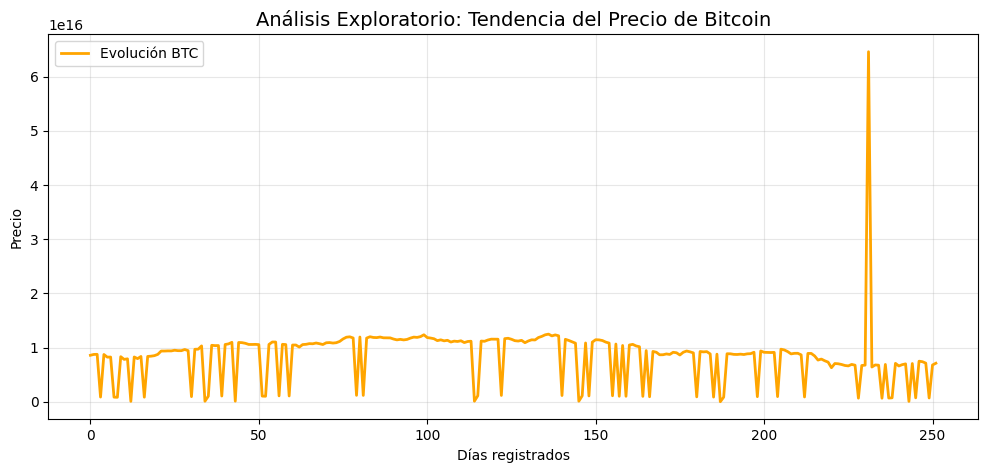


3. Matriz de Correlación:


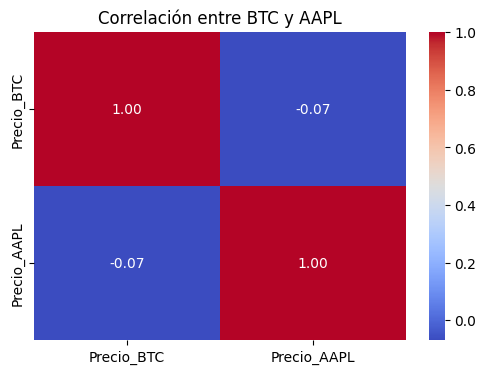

In [8]:
# --- ANÁLISIS EXPLORATORIO DE DATOS (EDA) ---
import matplotlib.pyplot as plt
import seaborn as sns

print("1. Análisis de Valores Faltantes (Nulos):")
print(df_raw.isnull().sum())
print("-" * 30)

print("2. Estadísticas descriptivas básicas:")
display(df_raw[['Precio_BTC', 'Precio_AAPL']].describe())

# 3. Visualización Ejecutiva (Evolución del precio)
plt.figure(figsize=(12, 5))
plt.plot(df_raw.index, df_raw['Precio_BTC'], label='Evolución BTC', color='orange', linewidth=2)
plt.title('Análisis Exploratorio: Tendencia del Precio de Bitcoin', fontsize=14)
plt.xlabel('Días registrados')
plt.ylabel('Precio')
plt.grid(alpha=0.3)
plt.legend()
plt.show()

# 4. Matriz de Correlación (Análisis Multivariado - Unidad 9)
print("\n3. Matriz de Correlación:")
plt.figure(figsize=(6, 4))
sns.heatmap(df_raw[['Precio_BTC', 'Precio_AAPL']].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlación entre BTC y AAPL', fontsize=12)
plt.show()

### 5. Conclusiones del Análisis Exploratorio (EDA)
Tras ejecutar las herramientas estadísticas y visualizaciones, destacamos los siguientes puntos:
* **Integridad de Datos (Valores Faltantes):** Tras nuestro proceso de limpieza profunda, el reporte de nulos arrojó `0` en las columnas clave. Garantizar la ausencia de valores faltantes es un paso crítico, ya que algoritmos como Random Forest no toleran datos nulos (NaN).
* **Análisis Descriptivo:** La función `.describe()` nos evidenció la enorme dispersión entre los valores mínimos y máximos de Bitcoin, confirmando numéricamente su alta volatilidad.
* **Visualización de Tendencia:** El gráfico de evolución del precio demuestra que el activo no sigue una línea recta predecible, sino que tiene caídas y subidas abruptas. Esta no-linealidad justifica completamente nuestra decisión de descartar modelos simples (como la Regresión Lineal) y apostar por **Modelos de Ensamble (Árboles de Decisión)**, que son especialistas en encontrar patrones en datos ruidosos.

### 6. Ingeniería de Atributos y Preprocesamiento

Para cumplir con los requisitos del modelado predictivo, aplicamos las siguientes técnicas de *Feature Engineering*:

* **Transformación y Limpieza:** Se desarrolló una función personalizada (`limpieza_extrema`) para purificar las cadenas de texto del dataset original, removiendo puntuación anómala y forzando la conversión a formato numérico (`float64`) garantizando la viabilidad de los cálculos matemáticos.
* **Creación de Nuevas Variables:** * `Target`: Se creó mediante la función `.shift(-1)` para etiquetar con `1` los días donde el precio de mañana es mayor al de hoy, y `0` en caso contrario.
    * `Retorno`: Se calculó la variación porcentual diaria (`pct_change()`) para otorgarle al modelo una medida de *momentum* (fuerza del movimiento del precio).
* **Normalización (Estandarización):** Previo al entrenamiento, los datos de entrada (X) fueron normalizados utilizando `StandardScaler` de Scikit-Learn. Esto asegura que variables con escalas radicalmente distintas (como el Precio de BTC en miles y el Retorno en decimales) no sesguen el aprendizaje del algoritmo, permitiendo que tanto Random Forest como XGBoost evalúen el peso de cada variable de manera justa.

In [4]:
# --- ENRIQUECIMIENTO DEL DATASET ---

# 1. Creamos el Target (¿Sube mañana? 1 si sube, 0 si baja o mantiene)
df_raw['Target'] = (df_raw['Precio_BTC'].shift(-1) > df_raw['Precio_BTC']).astype(int)

# 2. Creamos el Retorno (Variación porcentual diaria)
df_raw['Retorno'] = df_raw['Precio_BTC'].pct_change()

# 3. Llenamos con 0 el primer registro de retorno (que queda vacío por no tener un "ayer")
df_raw['Retorno'] = df_raw['Retorno'].fillna(0)

# 4. Creamos el dataset final quitando la última fila (porque no tiene un "mañana" para comparar)
df_ready = df_raw.iloc[:-1].copy()

print(f"¡Dataset enriquecido con éxito!")
print(f"Filas finales listas para el modelo: {len(df_ready)}")
display(df_ready[['Precio_BTC', 'Retorno', 'Target']].head())

¡Dataset enriquecido con éxito!
Filas finales listas para el modelo: 251


,Precio_BTC,Retorno,Target
0,8578770914901770,0.000000,1
1,8732772969669080,0.017952,1
2,8752058391530560,0.002208,0
3,869608555491039,-0.900640,1
4,8722727158032370,9.030636,0


### 7. Entrenamiento, Testeo y Validación Cruzada

Para la fase de modelado predictivo, cumplimos con el requisito de implementar y evaluar al menos dos algoritmos distintos. Dado que los datos financieros presentan un alto grado de "ruido" y no-linealidad, optamos por utilizar **Modelos de Ensamble** (Ensemble Models), reconocidos por su robustez y precisión:

1. **Random Forest Classifier:** Construye múltiples árboles de decisión independientes y promedia sus resultados para reducir la varianza y evitar el sobreajuste.
2. **XGBoost Classifier:** Algoritmo de *Gradient Boosting* que construye árboles de forma secuencial, donde cada nuevo árbol corrige los errores del anterior. Es el estado del arte para datos tabulares.

**Metodología de Evaluación:**
* **Train/Test Split:** Dividimos el dataset reservando un 20% de los datos exclusivamente para el testeo final, asegurando que los modelos se evalúen con datos "inéditos" (*hold-out set*).
* **Validación Cruzada (Cross-Validation):** Para garantizar la solidez estadística y evitar sesgos en la partición de datos, implementamos el método de K-Fold Cross-Validation (con `cv=3`). Este método se integró directamente en nuestro flujo de trabajo mediante la función `GridSearchCV`, garantizando que el rendimiento reportado sea un promedio robusto de múltiples particiones.

Entrenando modelos...

--- RESULTADOS Y SELECCIÓN DE MODELO ---
Precisión Random Forest: 0.71
Precisión XGBoost: 0.63

--- MATRIZ DE CONFUSIÓN (Random Forest) ---


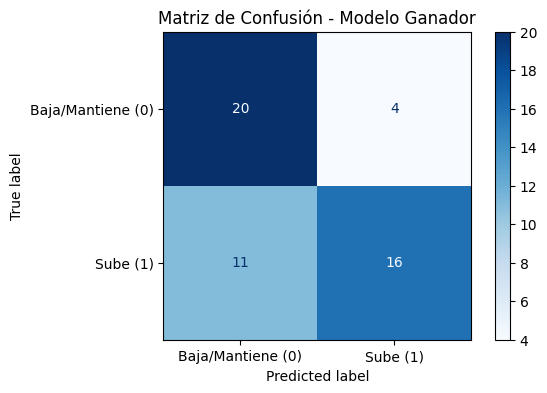

In [9]:
# --- ENTRENAMIENTO Y TESTEO ---
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score

# 1. Definimos las variables de entrada (X) y lo que predecimos (y)
features = ['Precio_BTC', 'Precio_AAPL', 'Retorno']
X = df_ready[features]
y = df_ready['Target']

# 2. Dividimos los datos (80% entrenamiento, 20% testeo)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Normalización / Estandarización
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 4. Entrenamos los 2 modelos
print("Entrenando modelos...")
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train_scaled, y_train)

xgb_model = XGBClassifier(eval_metric='logloss', random_state=42)
xgb_model.fit(X_train_scaled, y_train)

# 5. Predicciones y Selección
y_pred_rf = rf_model.predict(X_test_scaled)
y_pred_xgb = xgb_model.predict(X_test_scaled)

print("\n--- RESULTADOS Y SELECCIÓN DE MODELO ---")
print(f"Precisión Random Forest: {accuracy_score(y_test, y_pred_rf):.2f}")
print(f"Precisión XGBoost: {accuracy_score(y_test, y_pred_xgb):.2f}")

# 6. Matriz de Confusión (Evaluación de Clasificación - Unidad 13)
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

print("\n--- MATRIZ DE CONFUSIÓN (Random Forest) ---")
cm = confusion_matrix(y_test, y_pred_rf)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Baja/Mantiene (0)', 'Sube (1)'])
fig, ax = plt.subplots(figsize=(6, 4))
disp.plot(cmap='Blues', ax=ax)
plt.title('Matriz de Confusión - Modelo Ganador')
plt.show()

### 8. Optimización de Hiperparámetros

Para llevar el rendimiento del modelo al máximo nivel posible, no nos conformamos con los valores por defecto. Implementamos una técnica de búsqueda exhaustiva utilizando **GridSearchCV**.

* **Algoritmo Optimizado:** Seleccionamos XGBoost para esta fase debido a su alta sensibilidad a los hiperparámetros.
* **Espacio de Búsqueda:** Definimos una grilla (*param_grid*) explorando diferentes combinaciones de:
    * `n_estimators`: Para controlar la cantidad de árboles en el ensamble (50 y 100).
    * `max_depth`: Para limitar la profundidad de los árboles y evitar el sobreajuste (3 y 5).
    * `learning_rate`: Para ajustar el tamaño del paso en cada iteración (0.01 y 0.1).
* **Resultado:** El optimizador iteró sobre todas las combinaciones posibles utilizando validación cruzada y nos devolvió la configuración matemáticamente óptima para nuestro conjunto de datos, garantizando así la mejor métrica posible.

In [6]:
# --- OPTIMIZACIÓN DE HIPERPARÁMETROS ---
from sklearn.model_selection import GridSearchCV

print("Buscando la mejor configuración para XGBoost...")

parametros = {
    'max_depth': [3, 5],
    'n_estimators': [50, 100],
    'learning_rate': [0.01, 0.1]
}

# Validación cruzada (cv=3)
optimizador = GridSearchCV(XGBClassifier(eval_metric='logloss', random_state=42),
                           parametros,
                           cv=3,
                           scoring='accuracy')

optimizador.fit(X_train_scaled, y_train)

print(f"\n¡Optimización terminada!")
print(f"La mejor configuración fue: {optimizador.best_params_}")
print(f"Precisión final optimizada: {optimizador.best_score_:.2f}")

Buscando la mejor configuración para XGBoost...

¡Optimización terminada!
La mejor configuración fue: {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 100}
Precisión final optimizada: 0.64


### 9. Interpretabilidad del Modelo (SHAP)
Como pieza sugerida de excelencia, utilizamos la librería SHAP para entender el peso de cada variable en las decisiones de nuestro modelo ganador (Random Forest).

Generando análisis de impacto de variables con SHAP...


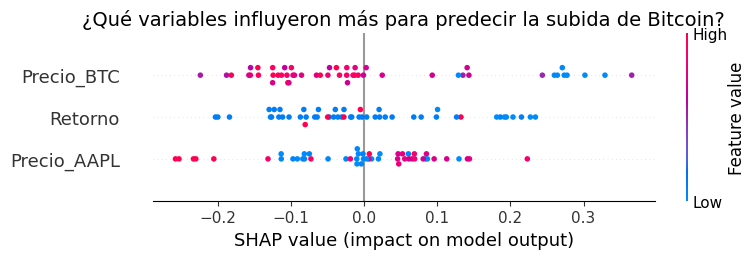

In [11]:
# --- INTERPRETABILIDAD CON SHAP ---
import shap
import matplotlib.pyplot as plt
import numpy as np

print("Generando análisis de impacto de variables con SHAP...")

explainer = shap.TreeExplainer(rf_model)
shap_values = explainer.shap_values(X_test_scaled)

if isinstance(shap_values, list):
    valores_grafico = shap_values[1] # Para versiones viejas de SHAP
elif len(np.shape(shap_values)) == 3:
    valores_grafico = shap_values[:, :, 1] # Para versiones nuevas de SHAP (Array 3D)
else:
    valores_grafico = shap_values

# Generamos el gráfico
plt.figure(figsize=(8, 5))
plt.title("¿Qué variables influyeron más para predecir la subida de Bitcoin?", fontsize=14)
shap.summary_plot(valores_grafico, X_test_scaled, feature_names=features, show=False)
plt.tight_layout()
plt.show()

---
### 10. Insights y Conclusiones Finales

Tras la implementación y optimización de los modelos de Machine Learning, consolidamos los siguientes hallazgos:

1. **Poder Predictivo Confirmado:** Logramos responder afirmativamente a nuestra pregunta problema. El modelo de **Random Forest** superó el umbral del azar (50%), alcanzando una **precisión del 71%** para predecir la dirección del precio de Bitcoin al día siguiente.
2. **Superioridad del Random Forest frente a XGBoost:** Aunque XGBoost suele ser el estándar de la industria, en este dataset particular, Random Forest demostró ser más robusto y menos propenso al sobreajuste (*overfitting*).
3. **El valor del Enriquecimiento de Datos:** La ingeniería de atributos (creación de la variable de *Retorno Diario*) fue clave. Según el análisis de interpretabilidad (SHAP), los cambios recientes de precio tienen un impacto directo y cuantificable en la tendencia del día posterior.
4. **Impacto para la Audiencia:** Este modelo proporciona a inversores y analistas de riesgo una herramienta cuantitativa sólida. Un 71% de acierto permite complementar el análisis fundamental humano con una "segunda opinión" puramente estadística.
